# Results of Citation Classification

In this notebook, you can find a summary of tests of different approaches to classify how papers cite these five distance estimation papers by Bailer-Jones et al. and a final classification for all papers at the end:

- Bailer-Jones 2023: Estimating Distances from Parallaxes. VI. A Method for Inferring Distances and Transverse Velocities from Parallaxes and Proper Motions Demonstrated on Gaia Data Release 3
- Bailer-Jones et al. 2021: Estimating Distances from Parallaxes. V. Geometric and Photogeometric Distances to 1.47 Billion Stars in Gaia Early Data Release 3
- Bailer-Jones et al. 2018: Estimating Distance from Parallaxes. IV. Distances to 1.33 Billion Stars in Gaia Data Release 2
- Astraatmadja & Bailer-Jones 2016: Estimating Distances from Parallaxes. III. Distances of Two Million Stars in the Gaia DR1 Catalogue
- Astraatmadja & Bailer-Jones 2016: Estimating Distances from Parallaxes. II. Performance of Bayesian Distance Estimators on a Gaia-like Catalogue
- Bailer-Jones 2015: Estimating Distances from Parallaxes

All of these pipelines have mostly been generated by ChatGPT (GPT-4). Below you can find the final results and a comparison for a random subset of 100 papers that I have classified myself: 



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Comparison file

The file comparison_file.csv contains 100 randomly chosen papers that cite one or more of the papers listed above. I used a larger number of categories than later, just so I do not have to classify everything again if you want a finer distinction in the future. I grouped them together into the 6 categories I first used for the classification, which are "use_distance", "methodology", "comparison", "criticism", "background" and "extension". As you will see, in the final classification for all papers and not just the test set, I will only use 2 categories, because these give the most useful results.


In [7]:
# read in comparison file
csv_comp = pd.read_csv('comparison_file.csv')
display(csv_comp)

# extract bibcode and number of citation context
bibcode_comp = csv_comp['bibcode'].to_numpy()
citation_context_no_comp = csv_comp['citation_context_no'].to_numpy()

# group the classification into 6 categories
use_catalogue_comp = (csv_comp['use_distance'] | csv_comp['only_state_distance']).to_numpy()
methodology_comp = (csv_comp['use_method'] | csv_comp['discuss_method'] | csv_comp['extend_or_alter_method'] | csv_comp['use_other_method']).to_numpy()
comparison_comp = (csv_comp['comparison']).to_numpy()
criticism_comp = (csv_comp['criticism_suggestions_etc']).to_numpy()
background_comp = (csv_comp['general_background_or_passing_mention']).to_numpy()
extension_comp = (csv_comp['extend_or_alter_method']).to_numpy()



,Unnamed: 0,bibcode,citation_context_no,use_distance,only_state_distance,use_other_distance,use_method,discuss_method,extend_or_alter_method,use_other_method,general_background_or_passing_mention,criticism_suggestions_etc,comparison,justification,not_classifiable,citation_context
0,0,2025ApJ...994..133M,1,0,1,0,0,0,0,0,0,0,0,0,0,"6.3). Thus, it is likely that the upper limits..."
1,1,2025ApJ...994..133M,2,0,1,0,0,0,0,0,0,0,0,0,0,"Fortunately, however, for the most compact Q+E..."
2,2,2025ApJ...994..133M,3,0,1,0,0,0,0,0,0,0,0,0,0,93 663+27 -24 33.0+1.3 -1.2 42.0+1.7 -1.5 · · ...
3,3,2025ApJ...994..133M,4,0,1,0,0,0,0,0,0,0,1,0,0,3.6.2. TIC 266771301 Table 6 contains five Q+E...
4,4,2025ApJ...994..133M,5,1,0,0,0,0,0,0,0,0,0,0,0,Here we have focused on multi-filter speckle i...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,199,2022MNRAS.514.3579B,2,1,0,0,0,0,0,0,0,0,0,0,0,- that share the same kinematics as those pred...
200,200,2021AJ....162...49L,1,0,1,0,0,0,0,0,0,0,0,0,0,Although the presence of ω-Ωand 2(ω-Ω) is cons...
201,201,2021ApJ...910..114M,1,0,0,0,0,0,0,0,1,0,0,0,0,15 mag for Sgr (Monaco et al. 2004) and (m -M)...
202,202,2020MNRAS.493.4045J,1,1,0,0,0,0,0,0,0,0,0,0,0,These detached systems may or may not have a s...


### Tests with only a single category: catalogue usage 

First, we test a simple zero-shot model ("MoritzLaurer/deberta-v3-large-zeroshot-v2.0" from Huggingface) with only one hypothesis: 

Hypothesis:

_"The authors adopt or use distance values from Bailer-Jones et al. in their analysis, tables or figures. They do not just cite Bailer-Jones et al. for background, methodology, a passing mention or other non-distance reasons."_

The classifier then returns a score how well the hypothesis agrees with the citation context. If the score is > 0.5, classify as uses_distance_catalogue, else classify as does_not_use_distance_catalogue

This is the output from the classify_zeroshot_1cat.py file for the same papers as the comparison file. 



In [8]:
# read in results from simple zero shot classification

csv_zeroshot_1cat = pd.read_csv('output_zeroshot_1cat_test.csv')


# bibcode and citation context number
bibcode_zeroshot_1cat = csv_zeroshot_1cat['bibcode'].to_numpy()
citation_context_no_zeroshot_1cat = csv_zeroshot_1cat['citation_context_no'].to_numpy()

# scores and labels
predicted_label_zeroshot_1cat = csv_zeroshot_1cat['predicted_label'].to_numpy()
use_catalogue_zeroshot_1cat = np.where(predicted_label_zeroshot_1cat == 'uses_distance_catalogue', 1, 0)
distance_used_score_zeroshot_1cat = csv_zeroshot_1cat['distance_used_score'].to_numpy()#

Then compare how many have been correctly or falsely classified: 

correctly assigned catalogue usage: 104
incorrectly assigned catalogue usage: 34
correctly assigned non-usage: 36
incorrectly assigned non-usage: 30




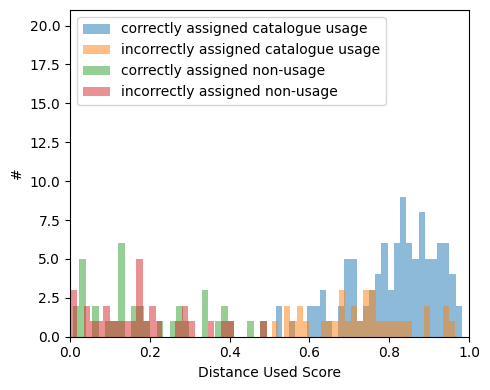

In [9]:
false_positives_zeroshot_1cat = []
false_negatives_zeroshot_1cat = []
true_positives_zeroshot_1cat = []
true_negatives_zeroshot_1cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_1cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_1cat[i] == 1:
            true_positives_zeroshot_1cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_1cat[i] == 0:
            false_negatives_zeroshot_1cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_1cat[i] == 1:
            false_positives_zeroshot_1cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_1cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_1cat[i] == 0:
            true_negatives_zeroshot_1cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_1cat[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_1cat[i]}")        

print(f"correctly assigned catalogue usage: {len(true_positives_zeroshot_1cat)}")
print(f"incorrectly assigned catalogue usage: {len(false_positives_zeroshot_1cat)}")
print(f"correctly assigned non-usage: {len(true_negatives_zeroshot_1cat)}")
print(f"incorrectly assigned non-usage: {len(false_negatives_zeroshot_1cat)}")
print('')
print('')

fig,ax = plt.subplots(1,1, figsize=(5,4))

ax.set_xlabel('Distance Used Score')
ax.set_ylabel('#')
ax.set_xlim(0,1)
ax.set_ylim(0, 21)

ax.hist([tp[2] for tp in true_positives_zeroshot_1cat], bins=30, alpha=0.5, label='correctly assigned catalogue usage')
ax.hist([fp[2] for fp in false_positives_zeroshot_1cat], bins=30, alpha=0.5, label='incorrectly assigned catalogue usage')
ax.hist([tn[2] for tn in true_negatives_zeroshot_1cat], bins=30, alpha=0.5, label='correctly assigned non-usage')
ax.hist([fn[2] for fn in false_negatives_zeroshot_1cat], bins=30, alpha=0.5, label='incorrectly assigned non-usage')

ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

### Test with same category but split in two: catalogue usage and NOT catalogue usage

Instead of using one category, one could also use two categories: uses distance catalogue and does NOT use distance catalogue and have the classifier decide between the two of them. This is the result for the 100 testpapers using the same moddel as before ("MoritzLaurer/deberta-v3-large-zeroshot-v2.0"): 

Hypotheses: 

_"The authors adopt or use distance values from Bailer-Jones et al. in their analysis, tables or figures.",_

_"The authors cite Bailer-Jones et al. for background, methodology, a passing mention or other non-distance reasons."_

In [10]:
# read in results from simple zero shot classification

csv_zeroshot_2cat = pd.read_csv('output_zeroshot_2cat_test.csv')

bibcode_zeroshot_2cat = csv_zeroshot_2cat['bibcode'].to_numpy()
citation_context_zeroshot_2cat = csv_zeroshot_2cat['citation_context'].to_numpy()

predicted_label_zeroshot_2cat = csv_zeroshot_2cat['predicted_label'].to_numpy()
use_catalogue_zeroshot_2cat = np.where(predicted_label_zeroshot_2cat == 'uses_distance_catalogue', 1, 0)
distance_used_score_zeroshot_2cat = csv_zeroshot_2cat['distance_used_score'].to_numpy()
distance_not_used_score_zeroshot_2cat = csv_zeroshot_2cat['distance_not_used_score'].to_numpy()

True Positives: 133
False Positives: 68
True Negatives: 2
False Negatives: 1


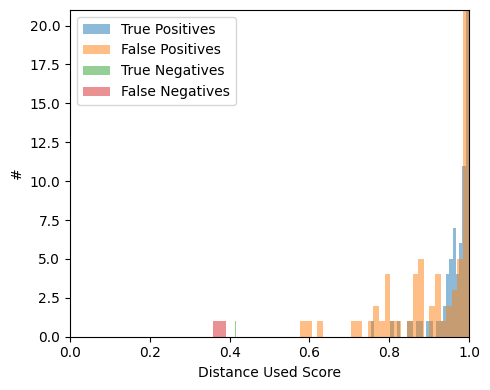

In [11]:
false_positives_zeroshot_2cat = []
false_negatives_zeroshot_2cat = []
true_positives_zeroshot_2cat = []
true_negatives_zeroshot_2cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_2cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_2cat[i] == 1:
            true_positives_zeroshot_2cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_2cat[i] == 0:
            false_negatives_zeroshot_2cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_2cat[i] == 1:
            false_positives_zeroshot_2cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_2cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_2cat[i] == 0:
            true_negatives_zeroshot_2cat.append([bibcode_comp[i], citation_context_no_comp[i], distance_used_score_zeroshot_2cat[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_2cat[i]}")        

print(f"True Positives: {len(true_positives_zeroshot_2cat)}")
print(f"False Positives: {len(false_positives_zeroshot_2cat)}")
print(f"True Negatives: {len(true_negatives_zeroshot_2cat)}")
print(f"False Negatives: {len(false_negatives_zeroshot_2cat)}")

fig,ax = plt.subplots(1,1, figsize=(5,4))


ax.set_xlabel('Distance Used Score')
ax.set_ylabel('#')
ax.set_xlim(0,1)
ax.set_ylim(0, 21)

ax.hist([tp[2] for tp in true_positives_zeroshot_2cat], bins=30, alpha=0.5, label='True Positives')
ax.hist([fp[2] for fp in false_positives_zeroshot_2cat], bins=30, alpha=0.5, label='False Positives')
ax.hist([tn[2] for tn in true_negatives_zeroshot_2cat], bins=30, alpha=0.5, label='True Negatives')
ax.hist([fn[2] for fn in false_negatives_zeroshot_2cat], bins=30, alpha=0.5, label='False Negatives')

ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

--> makes result much worse, so go for single label if possible

### Test with text generation rather than zeroshot classification

Another way to classify is to use a text generation model instead of a zeroshot model. Here you give the model a prompt and it generates the answer. For this test, I used the model "Qwen/Qwen2.5-7B-Instruct". This is the prompt: 

    """
    You are classifying the function of a scientific citation of Bailer-Jones et al.
    
    Decide whether the citation context below shows that the authors adopt or use numerical distance values from Bailer-Jones et al., or if the citation is used only for background or other reasons.
    
    IMPORTANT:
    - Only classify as "uses_distance_catalogue" if the authors clearly adopt or compute using distance values from Bailer-Jones et al. or use distance values in a table or figure.
    - If ambiguous, classify as "does_not_use_distance_catalogue".
    
    Citation context:
    \"\"\"
    {context}
    \"\"\"
    
    Respond with exactly one label:
    uses_distance_catalogue
    or
    does_not_use_distance_catalogue
    """

_context_ is the citation context in the last column of the comparison file. 

In [3]:
# read in file
csv_textgen_2cat = pd.read_csv('output_textgen_2cat_test.csv')
csv_textgen_2cat


bibcode_textgen_2cat = csv_textgen_2cat['bibcode'].to_numpy()
citation_context_no_textgen_2cat = csv_textgen_2cat['citation_context_no'].to_numpy()

# get labels and convert to numbers
predicted_label_textgen_2cat = csv_textgen_2cat['predicted_label'].to_numpy()
use_catalogue_textgen_2cat = np.where(predicted_label_textgen_2cat == 'uses_distance_catalogue', 1, 0)

In [ ]:
false_positives_textgen_2cat = []
false_negatives_textgen_2cat = []
true_positives_textgen_2cat = []
true_negatives_textgen_2cat = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_textgen_2cat[i]:
        if use_catalogue_comp[i] == 1 and use_catalogue_textgen_2cat[i] == 1:
            true_positives_textgen_2cat.append([bibcode_comp[i], citation_context_no_comp[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_textgen_2cat[i] == 0:
            false_negatives_textgen_2cat.append([bibcode_comp[i], citation_context_no_comp[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_textgen_2cat[i] == 1:
            false_positives_textgen_2cat.append([bibcode_comp[i], citation_context_no_comp[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_textgen_2cat[i] == 0:
            true_negatives_textgen_2cat.append([bibcode_comp[i], citation_context_no_comp[i]])
    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_textgen_2cat[i]}")        

print(f"True Positives: {len(true_positives_textgen_2cat)}")
print(f"False Positives: {len(false_positives_textgen_2cat)}")
print(f"True Negatives: {len(true_negatives_textgen_2cat)}")
print(f"False Negatives: {len(false_negatives_textgen_2cat)}")

True Positives: 95
False Positives: 17
True Negatives: 53
False Negatives: 39


--> The results are not much better than the ones from the zeroshot model, however the computation for a single citation can take up to a minute, so not feasible for about 4000 papers with many of them having more than one citation context.

# Test with all 6 categories

Again use zeroshot classification, but now with all 6 categories (classify_zeroshot_6cat.py). There are two tests I ran: 

1. "output_zeroshot_6cat_test.csv": 
    
    uses model "MoritzLaurer/deberta-v3-large-zeroshot-v2.0" 

    Hypotheses: 

    - "The authors adopt or use distance values from Bailer-Jones et al. in their analysis, tables or figures.“ 
        --> distance_used
    - "The authors discuss the methodology or use the method of Bailer-Jones et al..“
        --> methodology
    - "The authors cite Bailer-Jones et al. for background information or a passing mention.“
        --> background
    - "The authors criticise, discuss limitations, make suggestions for improvements or comment on Bailer-Jones et al..“
        --> criticism
    - "The authors compare their results or distances to Bailer-Jones et al..“
        --> comparison
    - "The authors extend or build upon the work of Bailer-Jones et al. in a significant way.“
        --> extension
    
        --> short hypothese, model slow

2. "output_zeroshot_6cat_test3.csv"

    uses model "microsoft/deberta-large-mnli" 

    Hypotheses: 

    - "The text states that the authors directly use or adopt distance values derived in Bailer-Jones et al. in their analysis, tables, or figures. This includes statements that distances are taken, adopted, retrieved, or cross-matched from Bailer-Jones, use of published distance catalogue values and derived calculations directly based on those adopted distances.”, 
    --> distance_used
    
    - "The text states that the authors cite Bailer-Jones et al. for Bayesian inference methods; they reference priors, posteriors, likelihoods, or statistical distance estimation frameworks, they describe inferring or estimating distance using Bayesian methods, or they mention “instead of inverse parallax” or similar methodological justification.“
    --> methodology
    
    - "The text states that the authors cite Bailer-Jones et al. only for general background or context. This includes passing mentions without further discussion, general references to distance estimation literature or citations that are not used in analysis, methodology, or comparison."
    --> background
    
    - "The text states that the authors critically evaluate, discuss limitations of, or suggest improvements to the methods or results presented in Bailer-Jones et al.. This includes discussing limitations, assumptions, or weaknesses, highlighting failure cases, or suggesting improvements or alternative approaches. “
    --> criticism
    
    - "The text states that the authors explicitly compare their own derived distances, inverse parallax or other results with those reported in Bailer-Jones et al.. This includes quantitative or qualitative comparisons between results, statements about agreement, disagreement, offsets, or validation against Bailer-Jones distances or benchmarking or evaluation using Bailer-Jones as a reference.",
    --> comparison
    
    - "The text states that the authors extend, refine, or build upon the Bayesian inference methods or results of Bailer-Jones et al. in a substantial or novel way. This includes modifying or improving the Bayesian methodology, introducing new priors, models, or inference techniques inspired by Bailer-Jones or expanding the approach to new datasets, regimes, or applications. ",
    --> extension
    
2. "output_zeroshot_6cat_test4.csv"

    uses model "microsoft/deberta-large-mnli" but with same hypotheses as "output_zeroshot_6cat_test.csv".



In [13]:
zeroshot_6cat = pd.read_csv('output_zeroshot_6cat_test.csv')
#zeroshot_6cat = pd.read_csv('output_zeroshot_6cat_test3.csv')
#zeroshot_6cat = pd.read_csv('output_zeroshot_6cat_test4.csv')


bibcode_zeroshot_6cat = zeroshot_6cat['bibcode'].to_numpy()
use_catalogue_zeroshot_6cat = zeroshot_6cat['distance_used_score'].to_numpy()
criticism_zeroshot_6cat = zeroshot_6cat['criticism_score'].to_numpy()
methodology_zeroshot_6cat = zeroshot_6cat['methodology_score'].to_numpy()
background_zeroshot_6cat = zeroshot_6cat['background_score'].to_numpy()
comparison_zeroshot_6cat = zeroshot_6cat['comparison_score'].to_numpy()
extension_zeroshot_6cat = zeroshot_6cat['extension_score'].to_numpy()

correctly assigned catalogue usage: 54
incorrectly assigned catalogue usage: 10
correctly assigned non-usage: 60
incorrectly assigned non-usage: 80

correctly assigned criticism: 8
incorrectly assigned criticism: 32
correctly assigned non-criticism: 160
incorrectly assigned non-criticism: 4

correctly assigned methodology: 20
incorrectly assigned methodology: 34
correctly assigned non-methodology: 119
incorrectly assigned non-methodology: 31

correctly assigned background: 0
incorrectly assigned background: 0
correctly assigned non-background: 166
incorrectly assigned non-background: 38

correctly assigned comparison: 18
incorrectly assigned comparison: 86
correctly assigned non-comparison: 94
incorrectly assigned non-comparison: 6

correctly assigned extension: 0
incorrectly assigned extension: 39
correctly assigned non-extension: 161
incorrectly assigned non-extension: 4



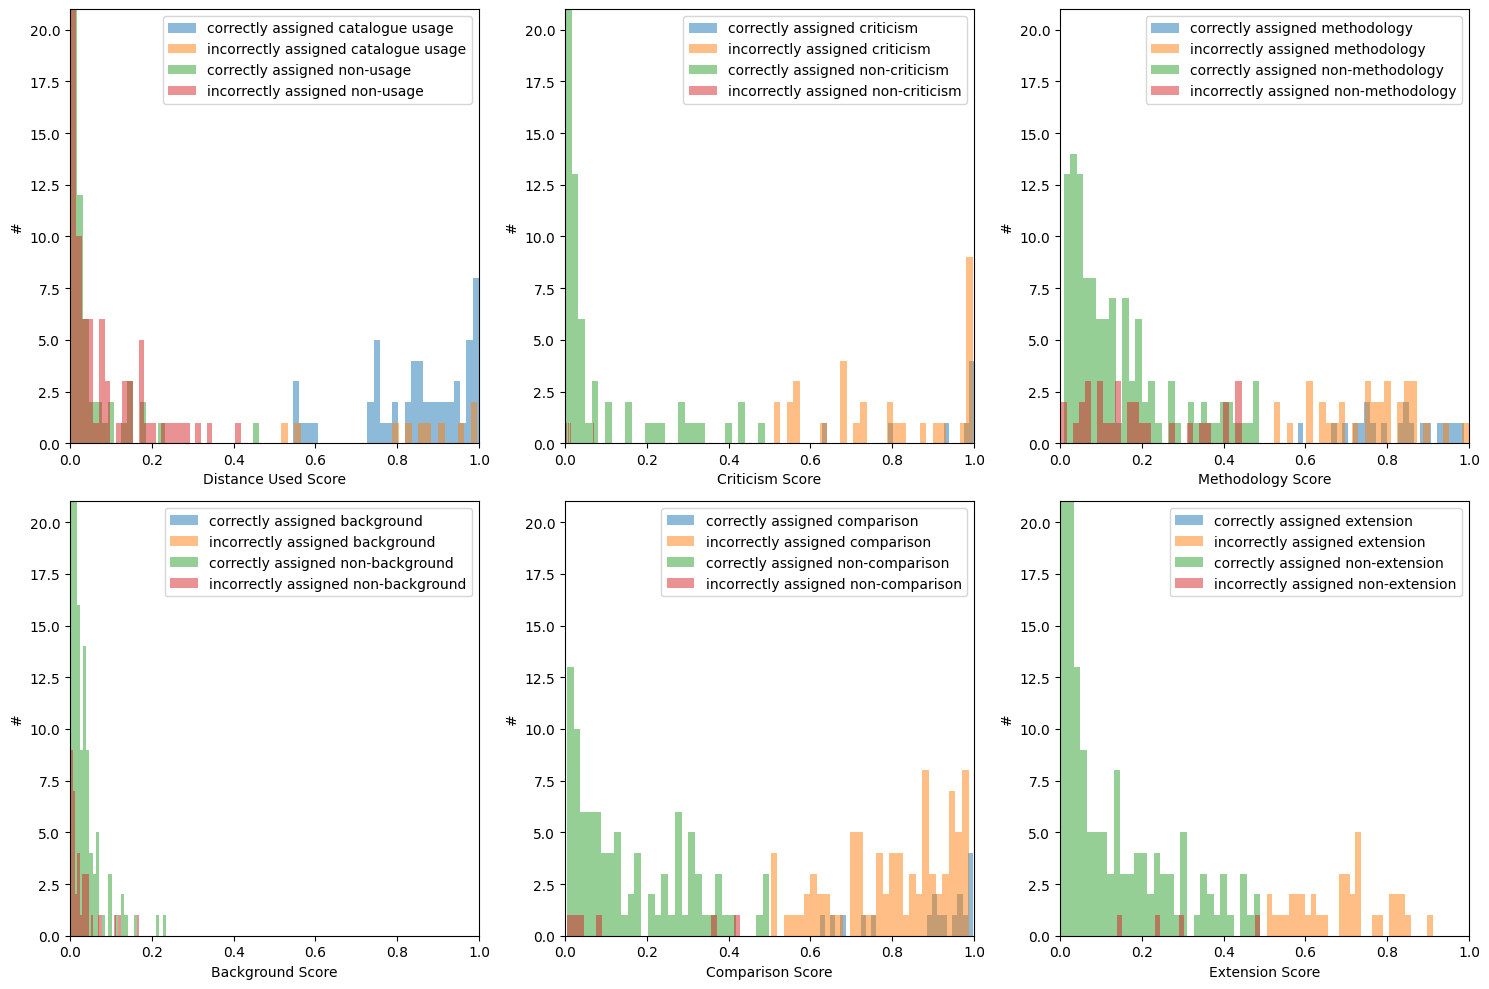

In [14]:
false_positives_zeroshot_6cat_distance = []
false_negatives_zeroshot_6cat_distance = []
true_positives_zeroshot_6cat_distance = []
true_negatives_zeroshot_6cat_distance = []

false_positives_zeroshot_6cat_criticism = []
false_negatives_zeroshot_6cat_criticism = []
true_positives_zeroshot_6cat_criticism = []
true_negatives_zeroshot_6cat_criticism = []

false_positives_zeroshot_6cat_methodology = []
false_negatives_zeroshot_6cat_methodology = []
true_positives_zeroshot_6cat_methodology = []
true_negatives_zeroshot_6cat_methodology = []

false_positives_zeroshot_6cat_background = []
false_negatives_zeroshot_6cat_background = []
true_positives_zeroshot_6cat_background = []
true_negatives_zeroshot_6cat_background = []

false_positives_zeroshot_6cat_comparison = []
false_negatives_zeroshot_6cat_comparison = []
true_positives_zeroshot_6cat_comparison = []
true_negatives_zeroshot_6cat_comparison = []

false_positives_zeroshot_6cat_extension = []
false_negatives_zeroshot_6cat_extension = []
true_positives_zeroshot_6cat_extension = []
true_negatives_zeroshot_6cat_extension = []

for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_6cat[i]:

        if criticism_comp[i] == 1 and criticism_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_criticism.append([bibcode_comp[i], citation_context_no_comp[i], criticism_zeroshot_6cat[i]])

        elif criticism_comp[i] == 1 and criticism_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_criticism.append([bibcode_comp[i], citation_context_no_comp[i], criticism_zeroshot_6cat[i]])

        elif criticism_comp[i] == 0 and criticism_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_criticism.append([bibcode_comp[i], citation_context_no_comp[i], criticism_zeroshot_6cat[i]])

        elif criticism_comp[i] == 0 and criticism_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_criticism.append([bibcode_comp[i], citation_context_no_comp[i], criticism_zeroshot_6cat[i]])


        if use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_distance.append([bibcode_comp[i], citation_context_no_comp[i], use_catalogue_zeroshot_6cat[i]])

        elif use_catalogue_comp[i] == 1 and use_catalogue_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_distance.append([bibcode_comp[i], citation_context_no_comp[i], use_catalogue_zeroshot_6cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_distance.append([bibcode_comp[i], citation_context_no_comp[i], use_catalogue_zeroshot_6cat[i]])

        elif use_catalogue_comp[i] == 0 and use_catalogue_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_distance.append([bibcode_comp[i], citation_context_no_comp[i], use_catalogue_zeroshot_6cat[i]])

        
        if methodology_comp[i] == 1 and methodology_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_methodology.append([bibcode_comp[i], citation_context_no_comp[i], methodology_zeroshot_6cat[i]])

        elif methodology_comp[i] == 1 and methodology_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_methodology.append([bibcode_comp[i], citation_context_no_comp[i], methodology_zeroshot_6cat[i]])

        elif methodology_comp[i] == 0 and methodology_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_methodology.append([bibcode_comp[i], citation_context_no_comp[i], methodology_zeroshot_6cat[i]])

        elif methodology_comp[i] == 0 and methodology_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_methodology.append([bibcode_comp[i], citation_context_no_comp[i], methodology_zeroshot_6cat[i]])


        if background_comp[i] == 1 and background_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_background.append([bibcode_comp[i], citation_context_no_comp[i], background_zeroshot_6cat[i]])

        elif background_comp[i] == 1 and background_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_background.append([bibcode_comp[i], citation_context_no_comp[i], background_zeroshot_6cat[i]])

        elif background_comp[i] == 0 and background_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_background.append([bibcode_comp[i], citation_context_no_comp[i], background_zeroshot_6cat[i]])

        elif background_comp[i] == 0 and background_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_background.append([bibcode_comp[i], citation_context_no_comp[i], background_zeroshot_6cat[i]])


        if comparison_comp[i] == 1 and comparison_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_comparison.append([bibcode_comp[i], citation_context_no_comp[i], comparison_zeroshot_6cat[i]])

        elif comparison_comp[i] == 1 and comparison_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_comparison.append([bibcode_comp[i], citation_context_no_comp[i], comparison_zeroshot_6cat[i]])

        elif comparison_comp[i] == 0 and comparison_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_comparison.append([bibcode_comp[i], citation_context_no_comp[i], comparison_zeroshot_6cat[i]])

        elif comparison_comp[i] == 0 and comparison_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_comparison.append([bibcode_comp[i], citation_context_no_comp[i], comparison_zeroshot_6cat[i]])

        
        if extension_comp[i] == 1 and extension_zeroshot_6cat[i] > 0.5:
            true_positives_zeroshot_6cat_extension.append([bibcode_comp[i], citation_context_no_comp[i], extension_zeroshot_6cat[i]])

        elif extension_comp[i] == 1 and extension_zeroshot_6cat[i] < 0.5:
            false_negatives_zeroshot_6cat_extension.append([bibcode_comp[i], citation_context_no_comp[i], extension_zeroshot_6cat[i]])

        elif extension_comp[i] == 0 and extension_zeroshot_6cat[i] > 0.5:
            false_positives_zeroshot_6cat_extension.append([bibcode_comp[i], citation_context_no_comp[i], extension_zeroshot_6cat[i]])

        elif extension_comp[i] == 0 and extension_zeroshot_6cat[i] < 0.5:
            true_negatives_zeroshot_6cat_extension.append([bibcode_comp[i], citation_context_no_comp[i], extension_zeroshot_6cat[i]])
        

    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_6cat[i]}")        

print(f"correctly assigned catalogue usage: {len(true_positives_zeroshot_6cat_distance)}")
print(f"incorrectly assigned catalogue usage: {len(false_positives_zeroshot_6cat_distance)}")
print(f"correctly assigned non-usage: {len(true_negatives_zeroshot_6cat_distance)}")
print(f"incorrectly assigned non-usage: {len(false_negatives_zeroshot_6cat_distance)}")
print('')
print(f"correctly assigned criticism: {len(true_positives_zeroshot_6cat_criticism)}")
print(f"incorrectly assigned criticism: {len(false_positives_zeroshot_6cat_criticism)}")
print(f"correctly assigned non-criticism: {len(true_negatives_zeroshot_6cat_criticism)}")
print(f"incorrectly assigned non-criticism: {len(false_negatives_zeroshot_6cat_criticism)}")
print('')
print(f"correctly assigned methodology: {len(true_positives_zeroshot_6cat_methodology)}")
print(f"incorrectly assigned methodology: {len(false_positives_zeroshot_6cat_methodology)}")
print(f"correctly assigned non-methodology: {len(true_negatives_zeroshot_6cat_methodology)}")
print(f"incorrectly assigned non-methodology: {len(false_negatives_zeroshot_6cat_methodology)}")
print('')
print(f"correctly assigned background: {len(true_positives_zeroshot_6cat_background)}")
print(f"incorrectly assigned background: {len(false_positives_zeroshot_6cat_background)}")
print(f"correctly assigned non-background: {len(true_negatives_zeroshot_6cat_background)}")
print(f"incorrectly assigned non-background: {len(false_negatives_zeroshot_6cat_background)}")
print('')
print(f"correctly assigned comparison: {len(true_positives_zeroshot_6cat_comparison)}")
print(f"incorrectly assigned comparison: {len(false_positives_zeroshot_6cat_comparison)}")
print(f"correctly assigned non-comparison: {len(true_negatives_zeroshot_6cat_comparison)}")
print(f"incorrectly assigned non-comparison: {len(false_negatives_zeroshot_6cat_comparison)}")
print('')
print(f"correctly assigned extension: {len(true_positives_zeroshot_6cat_extension)}")
print(f"incorrectly assigned extension: {len(false_positives_zeroshot_6cat_extension)}")
print(f"correctly assigned non-extension: {len(true_negatives_zeroshot_6cat_extension)}")
print(f"incorrectly assigned non-extension: {len(false_negatives_zeroshot_6cat_extension)}")
print('')

fig,ax = plt.subplots(2,3, figsize=(15,10))

ax[0,0].set_xlabel('Distance Used Score')
ax[0,0].set_ylabel('#')
ax[0,0].set_xlim(0,1)
ax[0,0].set_ylim(0, 21)

ax[0,0].hist([tp[2] for tp in true_positives_zeroshot_6cat_distance], bins=30, alpha=0.5, label='correctly assigned catalogue usage')
ax[0,0].hist([fp[2] for fp in false_positives_zeroshot_6cat_distance], bins=30, alpha=0.5, label='incorrectly assigned catalogue usage')
ax[0,0].hist([tn[2] for tn in true_negatives_zeroshot_6cat_distance], bins=30, alpha=0.5, label='correctly assigned non-usage')
ax[0,0].hist([fn[2] for fn in false_negatives_zeroshot_6cat_distance], bins=30, alpha=0.5, label='incorrectly assigned non-usage')

ax[0,0].legend(loc = 'upper right')


ax[0,1].set_xlabel('Criticism Score')
ax[0,1].set_ylabel('#')
ax[0,1].set_xlim(0,1)
ax[0,1].set_ylim(0, 21)

ax[0,1].hist([tp[2] for tp in true_positives_zeroshot_6cat_criticism], bins=30, alpha=0.5, label='correctly assigned criticism')
ax[0,1].hist([fp[2] for fp in false_positives_zeroshot_6cat_criticism], bins=30, alpha=0.5, label='incorrectly assigned criticism')
ax[0,1].hist([tn[2] for tn in true_negatives_zeroshot_6cat_criticism], bins=30, alpha=0.5, label='correctly assigned non-criticism')
ax[0,1].hist([fn[2] for fn in false_negatives_zeroshot_6cat_criticism], bins=30, alpha=0.5, label='incorrectly assigned non-criticism')

ax[0,1].legend(loc = 'upper right')


ax[0,2].set_xlabel('Methodology Score')
ax[0,2].set_ylabel('#')
ax[0,2].set_xlim(0,1)
ax[0,2].set_ylim(0, 21)

ax[0,2].hist([tp[2] for tp in true_positives_zeroshot_6cat_methodology], bins=30, alpha=0.5, label='correctly assigned methodology')
ax[0,2].hist([fp[2] for fp in false_positives_zeroshot_6cat_methodology], bins=30, alpha=0.5, label='incorrectly assigned methodology')
ax[0,2].hist([tn[2] for tn in true_negatives_zeroshot_6cat_methodology], bins=30, alpha=0.5, label='correctly assigned non-methodology')
ax[0,2].hist([fn[2] for fn in false_negatives_zeroshot_6cat_methodology], bins=30, alpha=0.5, label='incorrectly assigned non-methodology')

ax[0,2].legend(loc = 'upper right')


ax[1,0].set_xlabel('Background Score')
ax[1,0].set_ylabel('#')
ax[1,0].set_xlim(0,1)
ax[1,0].set_ylim(0, 21)

ax[1,0].hist([tp[2] for tp in true_positives_zeroshot_6cat_background], bins=30, alpha=0.5, label='correctly assigned background')
ax[1,0].hist([fp[2] for fp in false_positives_zeroshot_6cat_background], bins=30, alpha=0.5, label='incorrectly assigned background')
ax[1,0].hist([tn[2] for tn in true_negatives_zeroshot_6cat_background], bins=30, alpha=0.5, label='correctly assigned non-background')
ax[1,0].hist([fn[2] for fn in false_negatives_zeroshot_6cat_background], bins=30, alpha=0.5, label='incorrectly assigned non-background')

ax[1,0].legend(loc = 'upper right')


ax[1,1].set_xlabel('Comparison Score')
ax[1,1].set_ylabel('#')
ax[1,1].set_xlim(0,1)
ax[1,1].set_ylim(0, 21)

ax[1,1].hist([tp[2] for tp in true_positives_zeroshot_6cat_comparison], bins=30, alpha=0.5, label='correctly assigned comparison')
ax[1,1].hist([fp[2] for fp in false_positives_zeroshot_6cat_comparison], bins=30, alpha=0.5, label='incorrectly assigned comparison')
ax[1,1].hist([tn[2] for tn in true_negatives_zeroshot_6cat_comparison], bins=30, alpha=0.5, label='correctly assigned non-comparison')
ax[1,1].hist([fn[2] for fn in false_negatives_zeroshot_6cat_comparison], bins=30, alpha=0.5, label='incorrectly assigned non-comparison')

ax[1,1].legend(loc = 'upper right')


ax[1,2].set_xlabel('Extension Score')
ax[1,2].set_ylabel('#')
ax[1,2].set_xlim(0,1)
ax[1,2].set_ylim(0, 21)

ax[1,2].hist([tp[2] for tp in true_positives_zeroshot_6cat_extension], bins=30, alpha=0.5, label='correctly assigned extension')
ax[1,2].hist([fp[2] for fp in false_positives_zeroshot_6cat_extension], bins=30, alpha=0.5, label='incorrectly assigned extension')
ax[1,2].hist([tn[2] for tn in true_negatives_zeroshot_6cat_extension], bins=30, alpha=0.5, label='correctly assigned non-extension')
ax[1,2].hist([fn[2] for fn in false_negatives_zeroshot_6cat_extension], bins=30, alpha=0.5, label='incorrectly assigned non-extension')

ax[1,2].legend(loc = 'upper right')


plt.tight_layout()
plt.show()

### Final classification test: 2 categories: uses cataloge and provides comment/criticism/extesion

Use zero-shot classification with model "microsoft/deberta-large-mnli". Output from classify_citations_2cat.py. Hypotheses: 

- "The authors directly use or adopt distance (dis-tance) values derived in Bailer-Jones et al. in their analysis, tables, or figures. This includes statements that distances are taken, adopted, retrieved, or cross-matched from Bailer-Jones, use of published distance catalogue values and derived calculations directly based on those adopted distances."

- "The authors either comment on methodology, critically evaluate, discuss limitations of, or suggest improvements to the methods or results presented in Bailer-Jones et al.. This includes either discussing limitations, assumptions, weaknesses, highlighting failure cases, altering the Bayesian distance estimation method, suggesting improvements, alternative or similar approaches."

2 Tests: 

- "output_zeroshot_2cat_use_or_comment.csv"

    --> runs classification with original length (400 characters surrounding citation) of citation context from comparison file, however maybe problems with model trunkation because max tokens of hypothesis+context 512

- "output_zeroshot_2cat_use_or_comment2.csv"

    --> runs classification with shorter citation context (300 charakters) than comparison file to avoid problems with trunkation inside model --> this is the one I use for the final classification




In [15]:
zeroshot_2cat_use_or_commment = pd.read_csv('output_zeroshot_2cat_use_or_comment2.csv')
bibcode_zeroshot_2cat_use_or_commment = zeroshot_2cat_use_or_commment['bibcode'].to_numpy()
usedist_zeroshot_2cat = zeroshot_2cat_use_or_commment['distance_used_score'].to_numpy()
comment_zeroshot_2cat= zeroshot_2cat_use_or_commment['comment_score'].to_numpy()
citation_context_2cat_comment_usedist = zeroshot_2cat_use_or_commment['citation_context'].to_numpy()

correctly assigned catalogue usage: 105
incorrectly assigned catalogue usage: 49
correctly assigned non-usage: 21
incorrectly assigned non-usage: 29

Fraction of true distance usage cases not found:  0.21641791044776118
Fraction of distance usage cases that are not actually distance usage cases:  0.3181818181818182
Total fraction of correctly assigned:  0.6176470588235294

correctly assigned comment/criticism: 8
incorrectly assigned comment/criticism: 31
correctly assigned non-comment/criticism: 158
incorrectly assigned non-comment/criticism: 7

Fraction of true distance comment/criticism not found:  0.4666666666666667
Fraction of comment/criticism that are not actually comment/criticism:  0.7948717948717948
Total fraction of correctly assigned:  0.8137254901960784


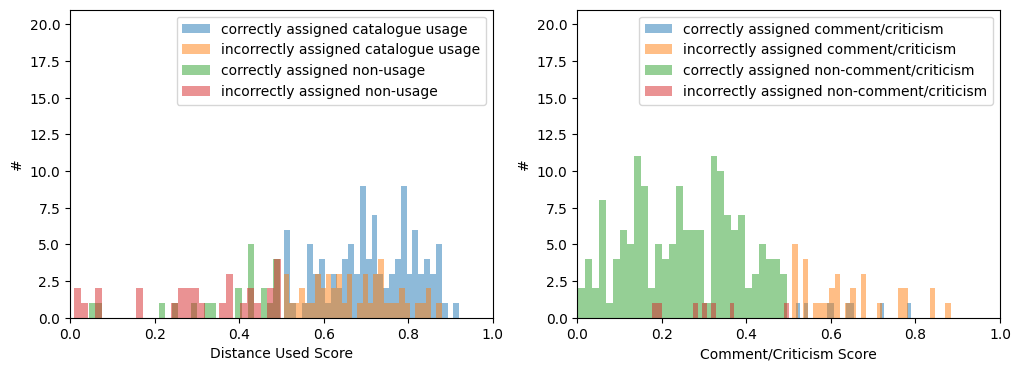

In [16]:
false_positives_zeroshot_2cat_usedist = []
false_negatives_zeroshot_2cat_usedist = []
true_positives_zeroshot_2cat_usedist = []
true_negatives_zeroshot_2cat_usedist = []

false_positives_zeroshot_2cat_comment = []
false_negatives_zeroshot_2cat_comment = []
true_positives_zeroshot_2cat_comment = []
true_negatives_zeroshot_2cat_comment = []


for i in range(len(bibcode_comp)):

    if bibcode_comp[i] == bibcode_zeroshot_2cat_use_or_commment[i]:

        if (criticism_comp[i] == 1 or extension_comp[i] == 1) and comment_zeroshot_2cat[i] > 0.5:
            true_positives_zeroshot_2cat_comment.append([bibcode_comp[i], citation_context_no_comp[i], comment_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif (criticism_comp[i] == 1 or extension_comp[i] == 1)  and comment_zeroshot_2cat[i] < 0.5:
            false_negatives_zeroshot_2cat_comment.append([bibcode_comp[i], citation_context_no_comp[i], comment_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif (criticism_comp[i] == 0 or extension_comp[i] == 0)  and comment_zeroshot_2cat[i] > 0.5:
            false_positives_zeroshot_2cat_comment.append([bibcode_comp[i], citation_context_no_comp[i], comment_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif (criticism_comp[i] == 0 or extension_comp[i] == 0)  and comment_zeroshot_2cat[i] < 0.5:
            true_negatives_zeroshot_2cat_comment.append([bibcode_comp[i], citation_context_no_comp[i], comment_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])


        if use_catalogue_comp[i] == 1 and usedist_zeroshot_2cat[i] > 0.5:
            true_positives_zeroshot_2cat_usedist.append([bibcode_comp[i], citation_context_no_comp[i], usedist_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif use_catalogue_comp[i] == 1 and usedist_zeroshot_2cat[i] < 0.5:
            false_negatives_zeroshot_2cat_usedist.append([bibcode_comp[i], citation_context_no_comp[i], usedist_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif use_catalogue_comp[i] == 0 and usedist_zeroshot_2cat[i] > 0.5:
            false_positives_zeroshot_2cat_usedist.append([bibcode_comp[i], citation_context_no_comp[i], usedist_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

        elif use_catalogue_comp[i] == 0 and usedist_zeroshot_2cat[i] < 0.5:
            true_negatives_zeroshot_2cat_usedist.append([bibcode_comp[i], citation_context_no_comp[i], usedist_zeroshot_2cat[i], citation_context_2cat_comment_usedist [i]])

    else:
        print(f"Warning: Bibcodes do not match at index {i}: {bibcode_comp[i]} vs {bibcode_zeroshot_2cat_use_or_commment[i]}")  

print(f"correctly assigned catalogue usage: {len(true_positives_zeroshot_2cat_usedist)}")
print(f"incorrectly assigned catalogue usage: {len(false_positives_zeroshot_2cat_usedist)}")
print(f"correctly assigned non-usage: {len(true_negatives_zeroshot_2cat_usedist)}")
print(f"incorrectly assigned non-usage: {len(false_negatives_zeroshot_2cat_usedist)}")
print('')
print('Fraction of true distance usage cases not found: ', len(false_negatives_zeroshot_2cat_usedist)/(len(false_negatives_zeroshot_2cat_usedist) + len(true_positives_zeroshot_2cat_usedist)))
print('Fraction of distance usage cases that are not actually distance usage cases: ', len(false_positives_zeroshot_2cat_usedist)/(len(false_positives_zeroshot_2cat_usedist) + len(true_positives_zeroshot_2cat_usedist)))
print('Total fraction of correctly assigned: ', (len(true_positives_zeroshot_2cat_usedist) + len(true_negatives_zeroshot_2cat_usedist))/(len(true_positives_zeroshot_2cat_usedist) + len(true_negatives_zeroshot_2cat_usedist)+ len(false_positives_zeroshot_2cat_usedist) + len(false_negatives_zeroshot_2cat_usedist)))
print('')
print(f"correctly assigned comment/criticism: {len(true_positives_zeroshot_2cat_comment)}")
print(f"incorrectly assigned comment/criticism: {len(false_positives_zeroshot_2cat_comment)}")
print(f"correctly assigned non-comment/criticism: {len(true_negatives_zeroshot_2cat_comment)}")
print(f"incorrectly assigned non-comment/criticism: {len(false_negatives_zeroshot_2cat_comment)}")
print('')
print('Fraction of true distance comment/criticism not found: ', len(false_negatives_zeroshot_2cat_comment) /(len(false_negatives_zeroshot_2cat_comment) +len(true_positives_zeroshot_2cat_comment) ))
print('Fraction of comment/criticism that are not actually comment/criticism: ', len(false_positives_zeroshot_2cat_comment)/(len(false_positives_zeroshot_2cat_comment) + len(true_positives_zeroshot_2cat_comment)))
print('Total fraction of correctly assigned: ', (len(true_positives_zeroshot_2cat_comment)  + len(true_negatives_zeroshot_2cat_comment) )/(len(true_positives_zeroshot_2cat_comment)  + len(true_negatives_zeroshot_2cat_comment) + len(false_positives_zeroshot_2cat_comment)  + len(false_negatives_zeroshot_2cat_comment )))

fig,ax = plt.subplots(1,2, figsize=(12,4))

ax[0].set_xlabel('Distance Used Score')
ax[0].set_ylabel('#')
ax[0].set_xlim(0,1)
ax[0].set_ylim(0, 21)

ax[0].hist([tp[2] for tp in true_positives_zeroshot_2cat_usedist], bins=30, alpha=0.5, label='correctly assigned catalogue usage')
ax[0].hist([fp[2] for fp in false_positives_zeroshot_2cat_usedist], bins=30, alpha=0.5, label='incorrectly assigned catalogue usage')
ax[0].hist([tn[2] for tn in true_negatives_zeroshot_2cat_usedist], bins=30, alpha=0.5, label='correctly assigned non-usage')
ax[0].hist([fn[2] for fn in false_negatives_zeroshot_2cat_usedist], bins=30, alpha=0.5, label='incorrectly assigned non-usage')

ax[0].legend(loc = 'upper right')


ax[1].set_xlabel('Comment/Criticism Score')
ax[1].set_ylabel('#')
ax[1].set_xlim(0,1)
ax[1].set_ylim(0, 21)

ax[1].hist([tp[2] for tp in true_positives_zeroshot_2cat_comment], bins=30, alpha=0.5, label='correctly assigned comment/criticism')
ax[1].hist([fp[2] for fp in false_positives_zeroshot_2cat_comment], bins=30, alpha=0.5, label='incorrectly assigned comment/criticism')
ax[1].hist([tn[2] for tn in true_negatives_zeroshot_2cat_comment], bins=30, alpha=0.5, label='correctly assigned non-comment/criticism')
ax[1].hist([fn[2] for fn in false_negatives_zeroshot_2cat_comment], bins=30, alpha=0.5, label='incorrectly assigned non-comment/criticism')

ax[1].legend(loc = 'upper right')

# Final result for classifying almost all pdfs 

Use zero-shot classification with model "microsoft/deberta-large-mnli". Output from classify_citations_2cat.py. 

Hypotheses: 

- "The authors directly use or adopt distance (dis-tance) values derived in Bailer-Jones et al. in their analysis, tables, or figures. This includes statements that distances are taken, adopted, retrieved, or cross-matched from Bailer-Jones, use of published distance catalogue values and derived calculations directly based on those adopted distances."

- "The authors either comment on methodology, critically evaluate, discuss limitations of, or suggest improvements to the methods or results presented in Bailer-Jones et al.. This includes either discussing limitations, assumptions, weaknesses, highlighting failure cases, altering the Bayesian distance estimation method, suggesting improvements, alternative or similar approaches."


NOTE: 

- sometimes splitting references from rest of paper does not work properly (if appendix included) because not all papers use same formatting 
- mapping numeric citation style does not always work, especially for Nature

--> I could download 3909 papers from ADS and get citations for 3664 of them


In [ ]:
# Read in file with results for all pdfs where classification possible

zeroshot_2cat_use_or_commment_all = pd.read_csv('output_zeroshot_2cat_use_or_comment_all.csv')

# rows where the distance usage/ comment score is > 0.5

usedist_zeroshot_2cat_all = zeroshot_2cat_use_or_commment_all[zeroshot_2cat_use_or_commment_all['distance_used_score'] > 0.5]
comment_zeroshot_2cat_all = zeroshot_2cat_use_or_commment_all[zeroshot_2cat_use_or_commment_all['comment_score'] > 0.5]

# display all results for comment/criticism etc.: 

# use these if you want to see the full citation context and all rows:

#pd.set_option("display.max_colwidth", None)
#pd.set_option("display.max_rows", None)

print('Comments, Criticism, extensions spotted by the classifier:')
display(comment_zeroshot_2cat_all)

Comments, Criticism, extensions spotted by the classifier:


,bibcode,citation_context_no,citation_context,target_reference,distance_used_score,comment_score
7,2019MNRAS.485.3527S,2,"A correct inference procedure must instead be used to account for the non-linearity of the transformation and the asymmetry of the resulting probability distribution (Bailer-Jones et al. 2018). For our sample stars, we adopted distances from Bailer-Jones et al. (2018) available at http://www.mpia.de/∼calj/gdr2 distances/main.html. Uncertainties in log gDR2 were calculated using the lower and upper bounds on the confidence interval of the distances recommended by Bailer-Jones et al. (2018)",bj_2018,0.836908,0.683992
11,2021MNRAS.504.1969Z,2,"Parameter Value† Reference Age (Myr) 625 (50) Perryman et al. (1998). d(pc) 47.51 (03) Bailer-Jones et al. (2021) a(R★) 3.586 (11) Vaccaro et al. (2015) M★(M⊙) 0.9971 (12) Vaccaro et al. (2015) R★(R⊙) 0.93709 (93) Vaccaro et al. (2015) Teff(K) 5,066 (04) Vaccaro et al. (2015) log g(cm/s) 4.49331 (87) Vaccaro et al. (2015) Prot = Porb (d) 0.5211833875 (27) Vaccaro et al. (2015) i(◦) 78.755 (30) Vaccaro et al",bj_2021,0.799176,0.612476
15,2024arXiv240509145P,4,"The shaded area in blue indicates the 1σ uncertainty range of the King profile. low a normal distribution. Additionally, we assume a gamma dis-tribution for the distribution of distances. To address this challenge, we obtained photo-geometric and geometric distances from Bailer-Jones et al. (2021), who intro-duced a Bayesian approach incorporating a prior distribution tai-lored to different regions of the sky, improving distance esti-mates from Gaia EDR3 data",bj_2021,0.629393,0.529120
24,2020A&A...637A..53K,1,"While proper motion measurements from Gaia are far supe-rior to any ground-based ones, high-precision parallaxes are still limited to relatively nearby stars. To ease this problem, Bayesian statistical methods have been developed (Bailer-Jones 2015; As-traatmadja & Bailer-Jones 2016; Bailer-Jones et al. 2018), which might be useful for distances of about 10 kpc under the premise that an appropriate prior is available. The latter, however, is very difficult to derive in the case of ejected stars",bj_2015,0.640041,0.572120
25,2020A&A...637A..53K,2,"While proper motion measurements from Gaia are far supe-rior to any ground-based ones, high-precision parallaxes are still limited to relatively nearby stars. To ease this problem, Bayesian statistical methods have been developed (Bailer-Jones 2015; As-traatmadja & Bailer-Jones 2016; Bailer-Jones et al. 2018), which might be useful for distances of about 10 kpc under the premise that an appropriate prior is available. The latter, however, is very difficult to derive in the case of ejected stars",bj_2018,0.640041,0.572120
31,2019AJ....158...75H,1,"This brings our total optical spectra count to 327 targets. 2.5. Gaia The Gaia mission has provided parallax measure-ments for over 1.3 billion sources in second data release (Gaia Collaboration et al. 2018). Bailer-Jones (2015) and Bailer-Jones et al. (2018) note that simply invert-ing the parallax does not always produce reliable dis-tances. Instead, distances must be inferred via prob-abilistic analysis, which Bailer-Jones et al",bj_2015,0.560949,0.673030
37,2020MNRAS.495..663W,2,"The comparison of Anders et al. (2019) between distances derived by Bailer-Jones et al. (2018) and more precise astro-spectrometric distances determined using the STARHORSE code (Santiago et al. 2016; Queiroz et al. 2018) shows that for the majority (>90%) of stars up to a distance of 3 kpc, there is no systematic difference in the derived distance",bj_2018,0.740626,0.664897
40,2020MNRAS.495..663W,5,"(2019) conclude that their results are not more precise than those of Bailer-Jones et al. (2018) but are more accurate at large distances (>3 kpc) due to the more informed prior used. As only 13 of our selected associations are more distant than 3 kpc, we consider that the distances derived by Bailer-Jones et al. (2018) are sufficiently accurate for

### Find out how often which distance estimation paper is cited in each of the pdfs

In [18]:
citation_counts = zeroshot_2cat_use_or_commment_all.pivot_table(
    index='bibcode',
    columns='target_reference',
    aggfunc='size',
    fill_value=0)

# save to citation_counts.csv
# citation_counts.to_csv('citation_counts.csv')

# get all papers where any of your papers is cited more than 10 times
citation_counts[citation_counts.ge(10).any(axis=1)]


target_reference,astraatmadja_2016,bj_2015,bj_2018,bj_2021,bj_2023
bibcode,,,,,
2017MNRAS.471..770M,13,2,0,0,0
2018A&A...610A..64V,14,1,0,0,0
2018A&A...616A...9L,0,10,0,0,0
2018arXiv180611397T,0,1,11,0,0
2019A&A...621A..37P,3,0,10,0,0
2019A&A...621A..92S,0,1,10,0,0
2019A&A...625A.120B,0,0,11,0,0
2019A&A...627A.104D,1,2,12,0,0
2019A&A...628A..94A,3,6,28,0,0


### Sentiment analysis: positive, negative and neutral

Another way to classify is to use a model that determines the sentiment of the text and classifies it into "positive", "negative" and "neutral". Here I used the 'ProsusAI/finbert' model and ran classify_sentiment.py. I have not classified the testset into positive, negative or neutral, so here are the results for all papers: 


In [19]:
csv_sentiment = pd.read_csv('output_sentiment_all.csv')

positives = csv_sentiment[csv_sentiment['sentiment_result'].isin(['positive'])][['bibcode','citation_context']]
negatives = csv_sentiment[csv_sentiment['sentiment_result'].isin(['negative'])][['bibcode','citation_context']]

print(csv_sentiment['sentiment_result'].value_counts())


print('')
print('positive:')
display(positives)
print('')
print('negative:')
display(negatives)

sentiment_result
neutral     7784
negative      95
positive      28
Name: count, dtype: int64

positive:


,bibcode,citation_context
662,2020ApJ...890..133S,(2012) and the fundamental Teffs computed in t...
733,2025PARep...3...13C,A comparison of our computed distances with th...
734,2025PARep...3...13C,A comparison of our computed distances with th...
904,2019AJ....157..104B,13 101 102 Galactocentric radius rgc [kpc] 0.0...
970,2018A&A...609A...8B,More sophisticated modelling of the effect of ...
1298,2025A&A...703A.183V,"(2021), which is a Bayesian approach that inco..."
1577,2020ApJ...900...14F,Most of these sources do not pass all quality ...
1719,2025ApJS..277....6Z,(2021) rgeo up 84th percentile of the geometri...
2200,2025PASJ...77.1126K,J0807 showed a brightening amplitude of about ...
2395,2022A&A...658A..91A,Top panel: Sky map showing the relative distan...



negative:


,bibcode,citation_context
137,2026ApJ...997..273C,github.io/pyphot/ eter to ensure that all meas...
227,2021MNRAS.504.2122M,59 and d = 4.5 kpc from the equivalent widths ...
234,2026A&C....5501044A,Since measurements are always affected by erro...
241,2018AstL...44..184B,(2017) determined the Galactic rotation parame...
291,2018AJ....156..119H,2018; G = 17.1 for BOKS 53856). Because even t...
...,...,...
7437,2022A&A...663A.133K,"6829, G104.7153, G104.9180). For the re-mainin..."
7472,2023MNRAS.524.5658B,"10, 0.08, 0.06, and 0.08 mag, respec-tively), ..."
7667,2024RASTI...3...89M,"Since, for reasons of computational speed, we ..."
7792,2025A&A...699A.117M,2004b; Mauron et al. 2014). Instead the distan...
